In [17]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [14]:
pd.__version__

'3.0.3'

In [2]:
train_transaction = pd.read_csv(
    "../data/raw/train_transaction.csv"
)

train_identity = pd.read_csv(
    "../data/raw/train_identity.csv"
)

test_transaction = pd.read_csv(
    "../data/raw/test_transaction.csv"
)

test_identity = pd.read_csv(
    "../data/raw/test_identity.csv"
)

In [3]:
print("Train Transaction:", train_transaction.shape)
print("Train Identity:", train_identity.shape)

print("Test Transaction:", test_transaction.shape)
print("Test Identity:", test_identity.shape)

Train Transaction: (590540, 394)
Train Identity: (144233, 41)
Test Transaction: (506691, 393)
Test Identity: (141907, 41)


In [4]:
train_transaction.columns.tolist()

['TransactionID',
 'isFraud',
 'TransactionDT',
 'TransactionAmt',
 'ProductCD',
 'card1',
 'card2',
 'card3',
 'card4',
 'card5',
 'card6',
 'addr1',
 'addr2',
 'dist1',
 'dist2',
 'P_emaildomain',
 'R_emaildomain',
 'C1',
 'C2',
 'C3',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'C9',
 'C10',
 'C11',
 'C12',
 'C13',
 'C14',
 'D1',
 'D2',
 'D3',
 'D4',
 'D5',
 'D6',
 'D7',
 'D8',
 'D9',
 'D10',
 'D11',
 'D12',
 'D13',
 'D14',
 'D15',
 'M1',
 'M2',
 'M3',
 'M4',
 'M5',
 'M6',
 'M7',
 'M8',
 'M9',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'V29',
 'V30',
 'V31',
 'V32',
 'V33',
 'V34',
 'V35',
 'V36',
 'V37',
 'V38',
 'V39',
 'V40',
 'V41',
 'V42',
 'V43',
 'V44',
 'V45',
 'V46',
 'V47',
 'V48',
 'V49',
 'V50',
 'V51',
 'V52',
 'V53',
 'V54',
 'V55',
 'V56',
 'V57',
 'V58',
 'V59',
 'V60',
 'V61',
 'V62',
 'V63',
 'V64',
 'V

In [5]:
train_identity.columns.tolist()

['TransactionID',
 'id_01',
 'id_02',
 'id_03',
 'id_04',
 'id_05',
 'id_06',
 'id_07',
 'id_08',
 'id_09',
 'id_10',
 'id_11',
 'id_12',
 'id_13',
 'id_14',
 'id_15',
 'id_16',
 'id_17',
 'id_18',
 'id_19',
 'id_20',
 'id_21',
 'id_22',
 'id_23',
 'id_24',
 'id_25',
 'id_26',
 'id_27',
 'id_28',
 'id_29',
 'id_30',
 'id_31',
 'id_32',
 'id_33',
 'id_34',
 'id_35',
 'id_36',
 'id_37',
 'id_38',
 'DeviceType',
 'DeviceInfo']

In [6]:
train_transaction.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), str(14)
memory usage: 1.7 GB


In [7]:
train_identity.info()

<class 'pandas.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  str    
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  str    
 16  id_16          129340 non-null  str    
 17  id_17          139369 non-null  float64


In [8]:
train_transaction["isFraud"].value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

In [9]:
train_transaction["isFraud"].value_counts(normalize=True) * 100

isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64

96.5% legitimate and 3.5% fraud. Therefore dataset is imbalanced

In [10]:
train = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

In [11]:
train.shape

(590540, 434)

This means there are 590540 transactions and 434 features

In [20]:
# save the merged dataset
path_to_data_interim = Path("../data/interim")
path_to_data_interim.mkdir(
    parents=True,
    exist_ok=True
)

train.to_pickle(f"{path_to_data_interim}/train_merged.pkl")


In [12]:
# Missing Value Analysis
missing = (
    train.isnull()
         .mean()
         .sort_values(ascending=False)
         * 100
)

missing.head(20)

id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_04    88.768923
id_03    88.768923
D6       87.606767
id_33    87.589494
id_09    87.312290
dtype: float64

In [13]:
# creating a table:
missing_df = pd.DataFrame({
    "missing_percent": missing
})

missing_df.head(20)

,missing_percent
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
id_26,99.125715
id_27,99.124699
id_23,99.124699
id_22,99.124699
dist2,93.628374


Several features have > 90% missing values

#### Transaction Amount Analysis


In [14]:
train["TransactionAmt"].describe()

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

1. **Observation-1:**
Mean = 134 and median = 68.8 

This indicate positive skew (right skew) meaning long tail stretched towards right.

2. **Observation-2:**
75th percentile = 125 and maximum = 31,937

There is huge gap indicating extreme transaction values.

3. **Observation-3:**
std = 239 and mean = 135

This indicates large spread and high variability.

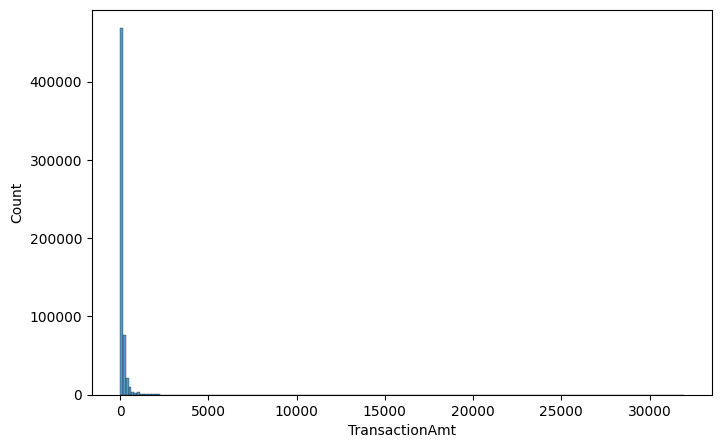

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    train['TransactionAmt'],
    bins=200
)

plt.show()

#### Fraud Rate by Amount

<Axes: xlabel='isFraud', ylabel='TransactionAmt'>

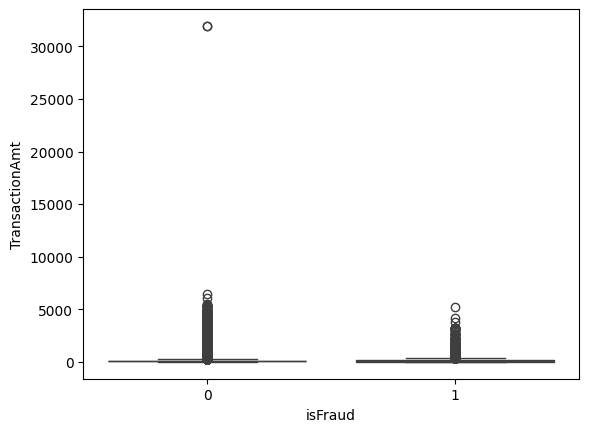

In [16]:
sns.boxplot(
    x='isFraud',
    y="TransactionAmt",
    data=train
)

# EDA Report

1. The merged IEEE-CIS dataset contains 590,540 transactions and 434 features. 

2. Fraudulent transactions account for approximately 3.5% of the dataset, indicating a moderately imbalanced classification problem. 

3. Several identity-related features contain more than 90% missing values and require further investigation before removal. 

4. The TransactionAmt feature is highly right-skewed with significant outliers, as evidenced by a mean of 135, median of 68.8, and maximum value of 31,937